# DLC_PIPELINE

This notebook interfaces with the Lake Lab DLC_FILTER_PIPELINE. It reads in a list of videos, and lets the user apply a preconfigured DLC pipeline to it along with custom filtering, Created 03/24/25

### POSE ESTIMATION AND FOOTSTEP EXTRACTION

2025-10-04 14:45:13.215 python[76751:3989424] The class 'NSOpenPanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


72 file paths written to selected_files.txt
Processing /Volumes/jzellers/Active/1_Projects/K01_obesity/TEST_GAIT3/20250930/AVI/20250930_2106_01.avi
Loading DLC 3.0.0rc9...
Analyzing videos with dlcfilterpipeline/dlc-models-pytorch/iteration-0/mouse_trackingMay19-trainset95shuffle1/train/snapshot-best-130.pt
Starting to analyze /Volumes/jzellers/Active/1_Projects/K01_obesity/TEST_GAIT3/20250930/AVI/20250930_2106_01.avi
Video metadata: 
  Overall # of frames:    1027
  Duration of video [s]:  34.23
  fps:                    30.0
  resolution:             w=1280, h=300

Running pose prediction with batch size 8


  1%|▏         | 15/1027 [02:08<2:37:17,  9.33s/it][ WARN:0@222.677] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 75977.521568 ms
[rawvideo @ 0x13e004fe0] Invalid buffer size, packet size 32760 < expected frame_size 2764800
  1%|▏         | 15/1027 [03:24<3:49:56, 13.63s/it]


Saving results in /Volumes/jzellers/Active/1_Projects/K01_obesity/TEST_GAIT3/20250930/AVI/20250930_2106_01DLC_Resnet50_mouse_trackingMay19shuffle1_snapshot_130.h5 and /Volumes/jzellers/Active/1_Projects/K01_obesity/TEST_GAIT3/20250930/AVI/20250930_2106_01DLC_Resnet50_mouse_trackingMay19shuffle1_snapshot_130_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

CREATED MODEL NAME IS:  DLC_Resnet50_mouse_trackingMay19shuffle1_snapshot_130
model_name is already in the class as:  DLC_Resnet50_mouse_trackingMay19shuffle1_snapshot_130
HDF5 file: /Volumes/jzellers/Active/1_Projects/K01_obesity/TEST_GAIT3/20250930/AVI/20250930_2106_01DLC_Resnet50_mouse_trackingMay19shuffle1_snapshot_130.h5 successfully loaded.
['scorer', 'bodyparts'

100%|██████████| 15/15 [00:06<00:00,  2.43it/s]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

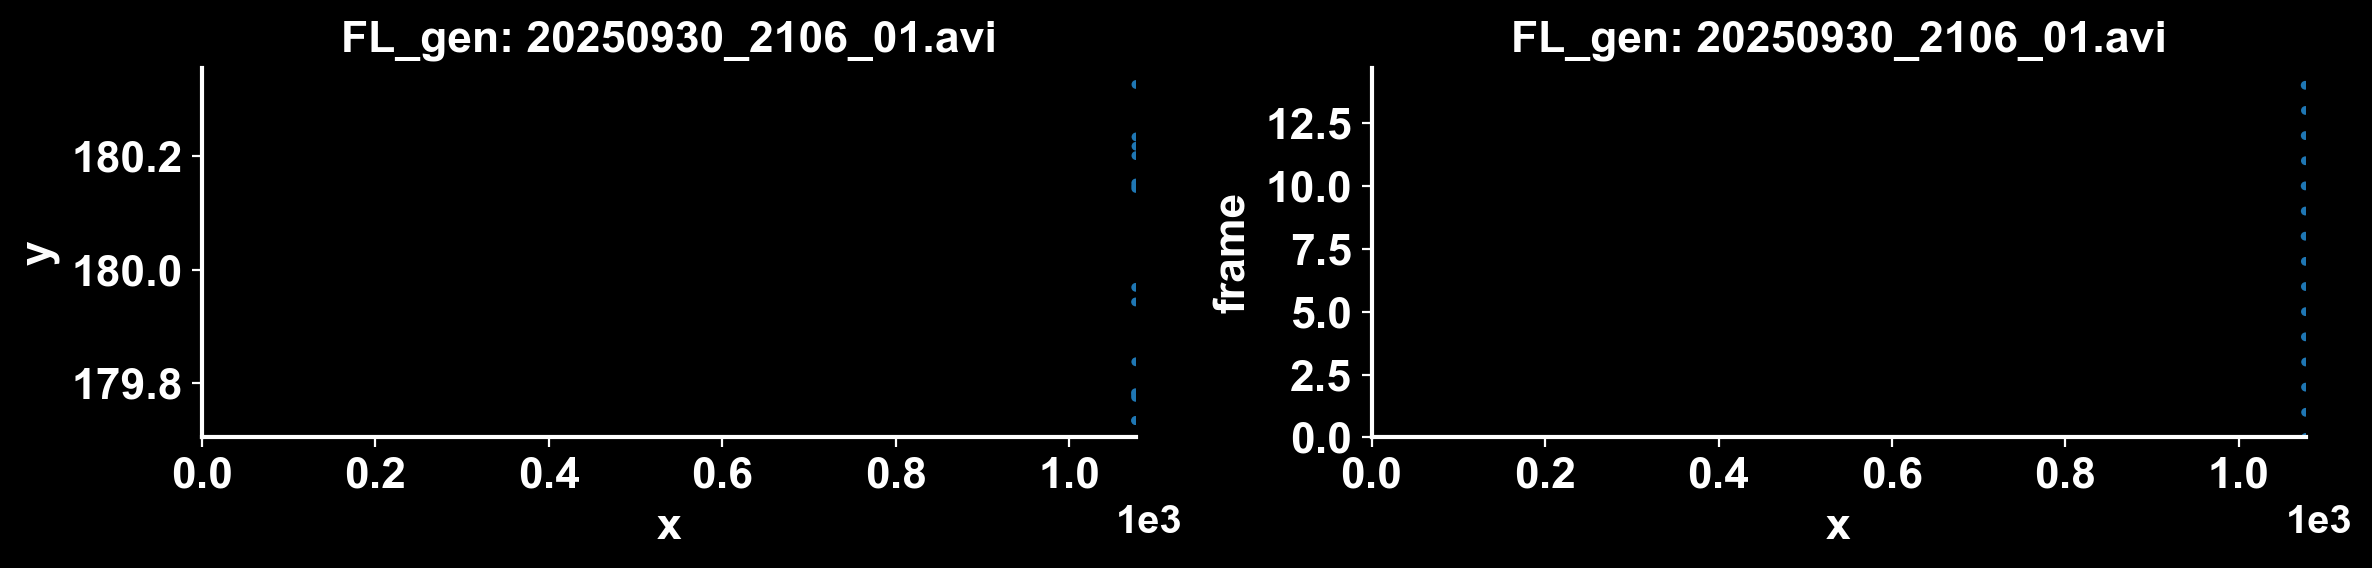

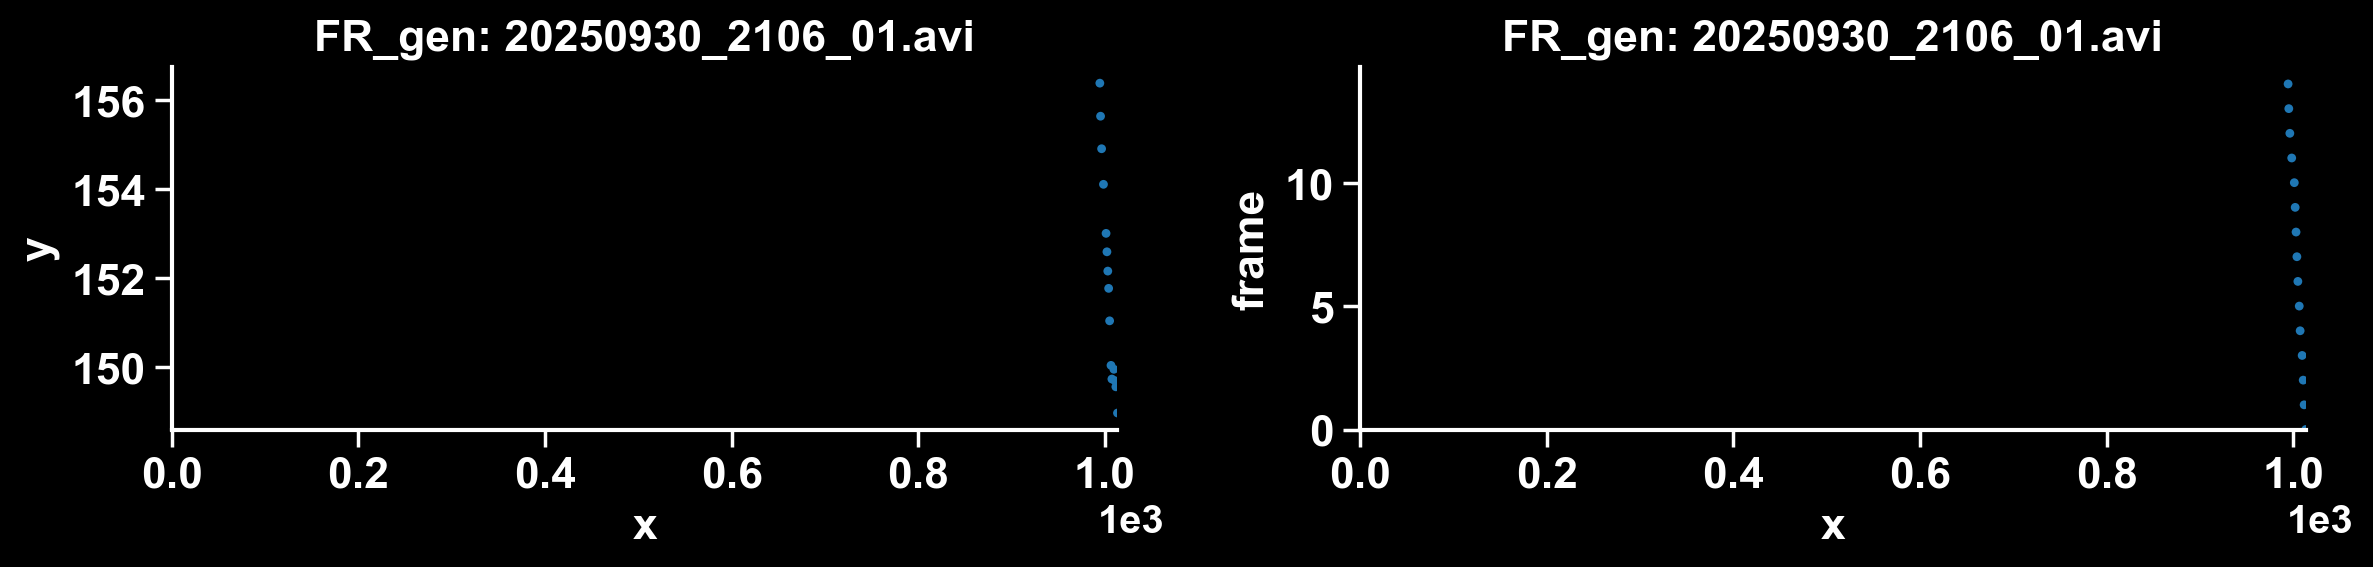

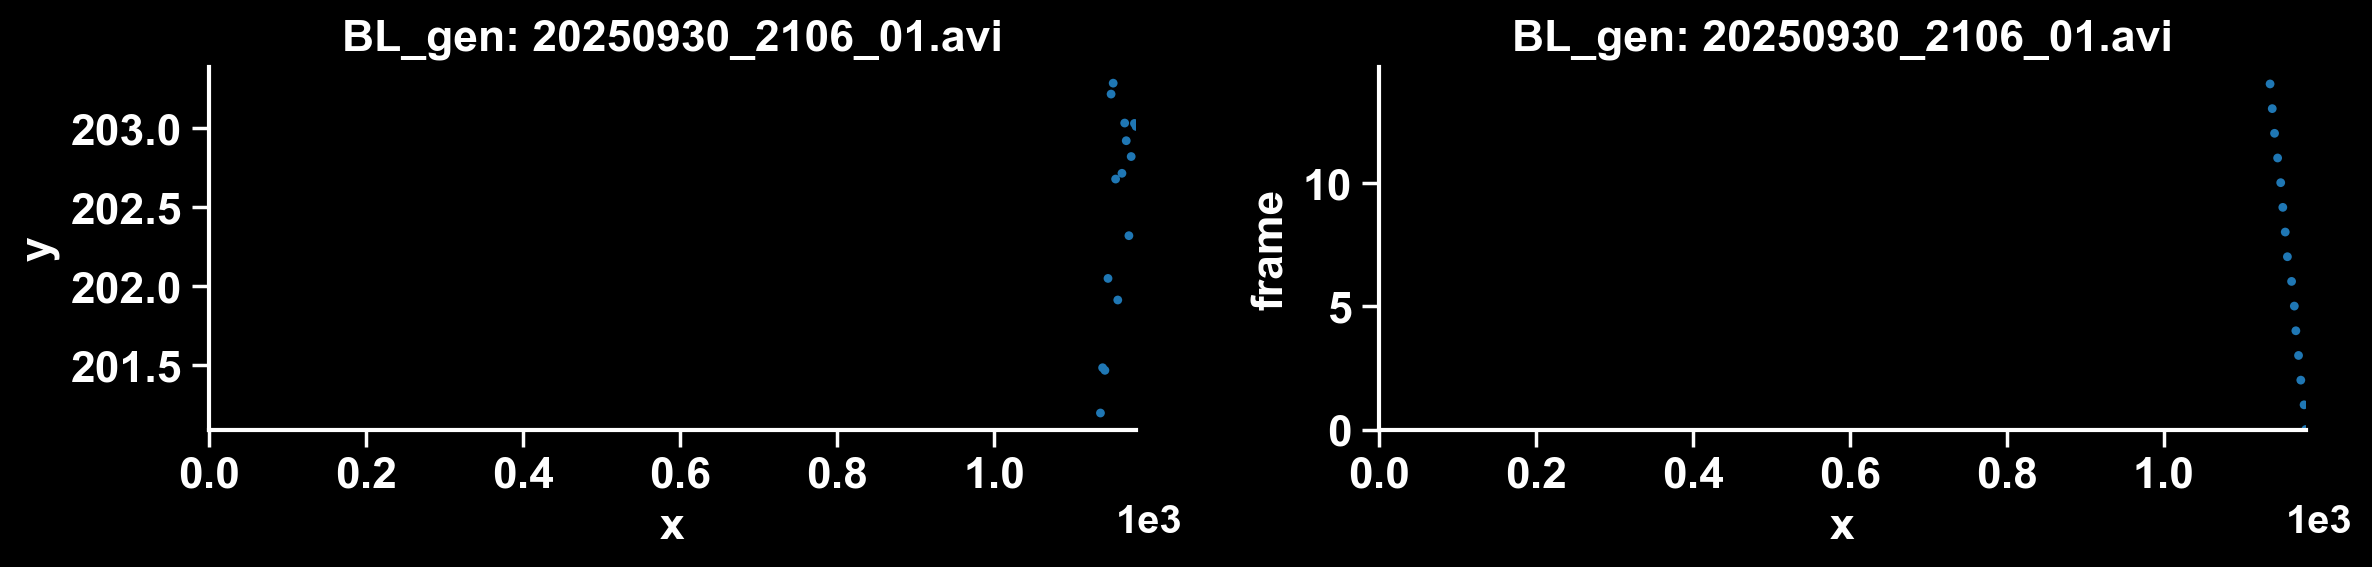

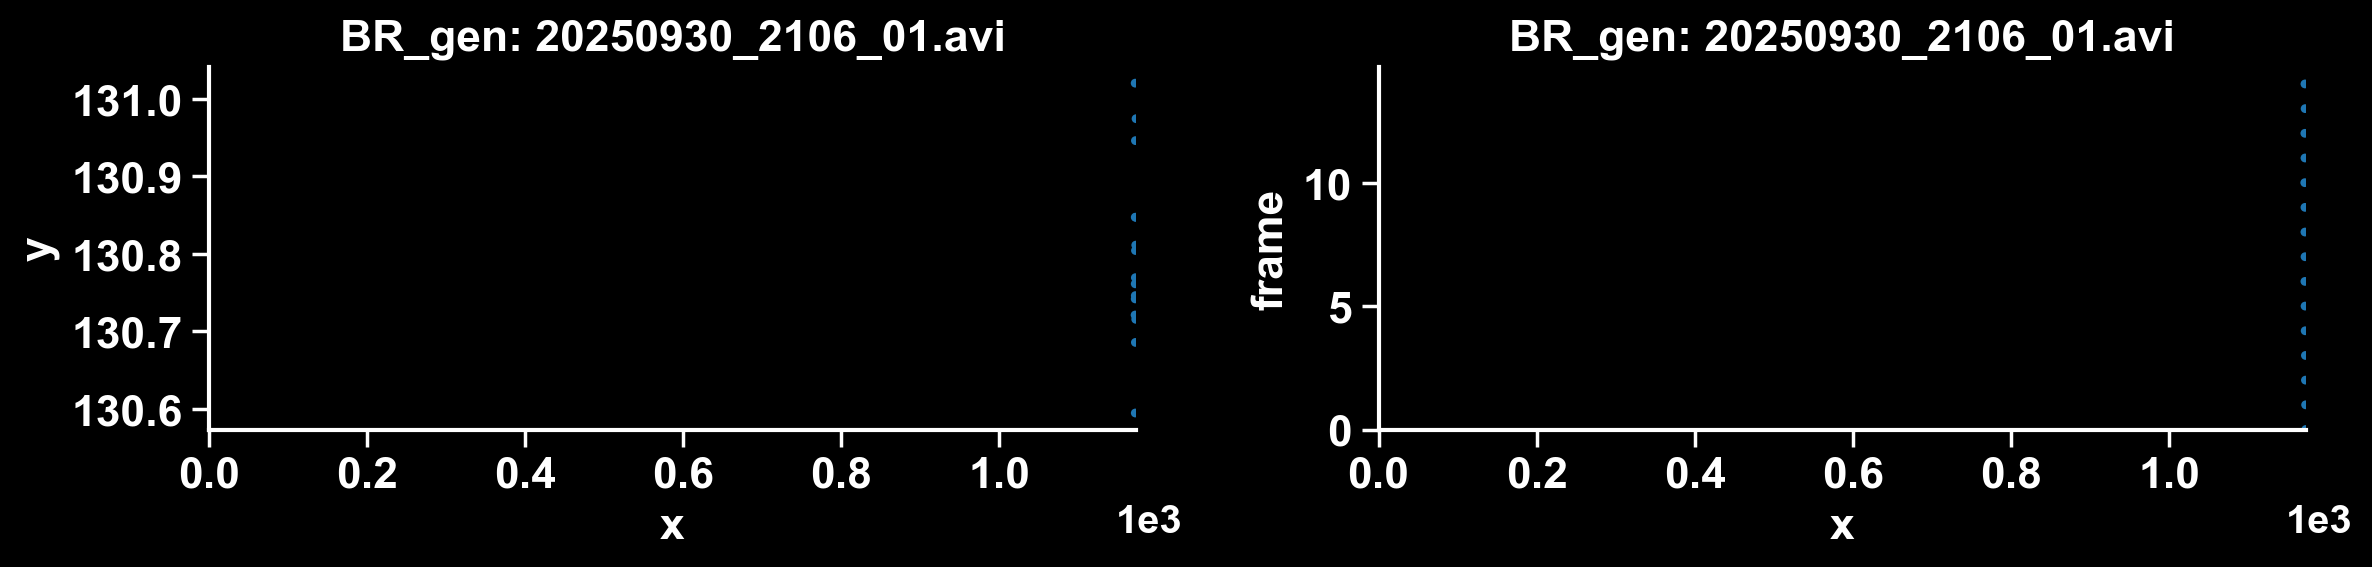

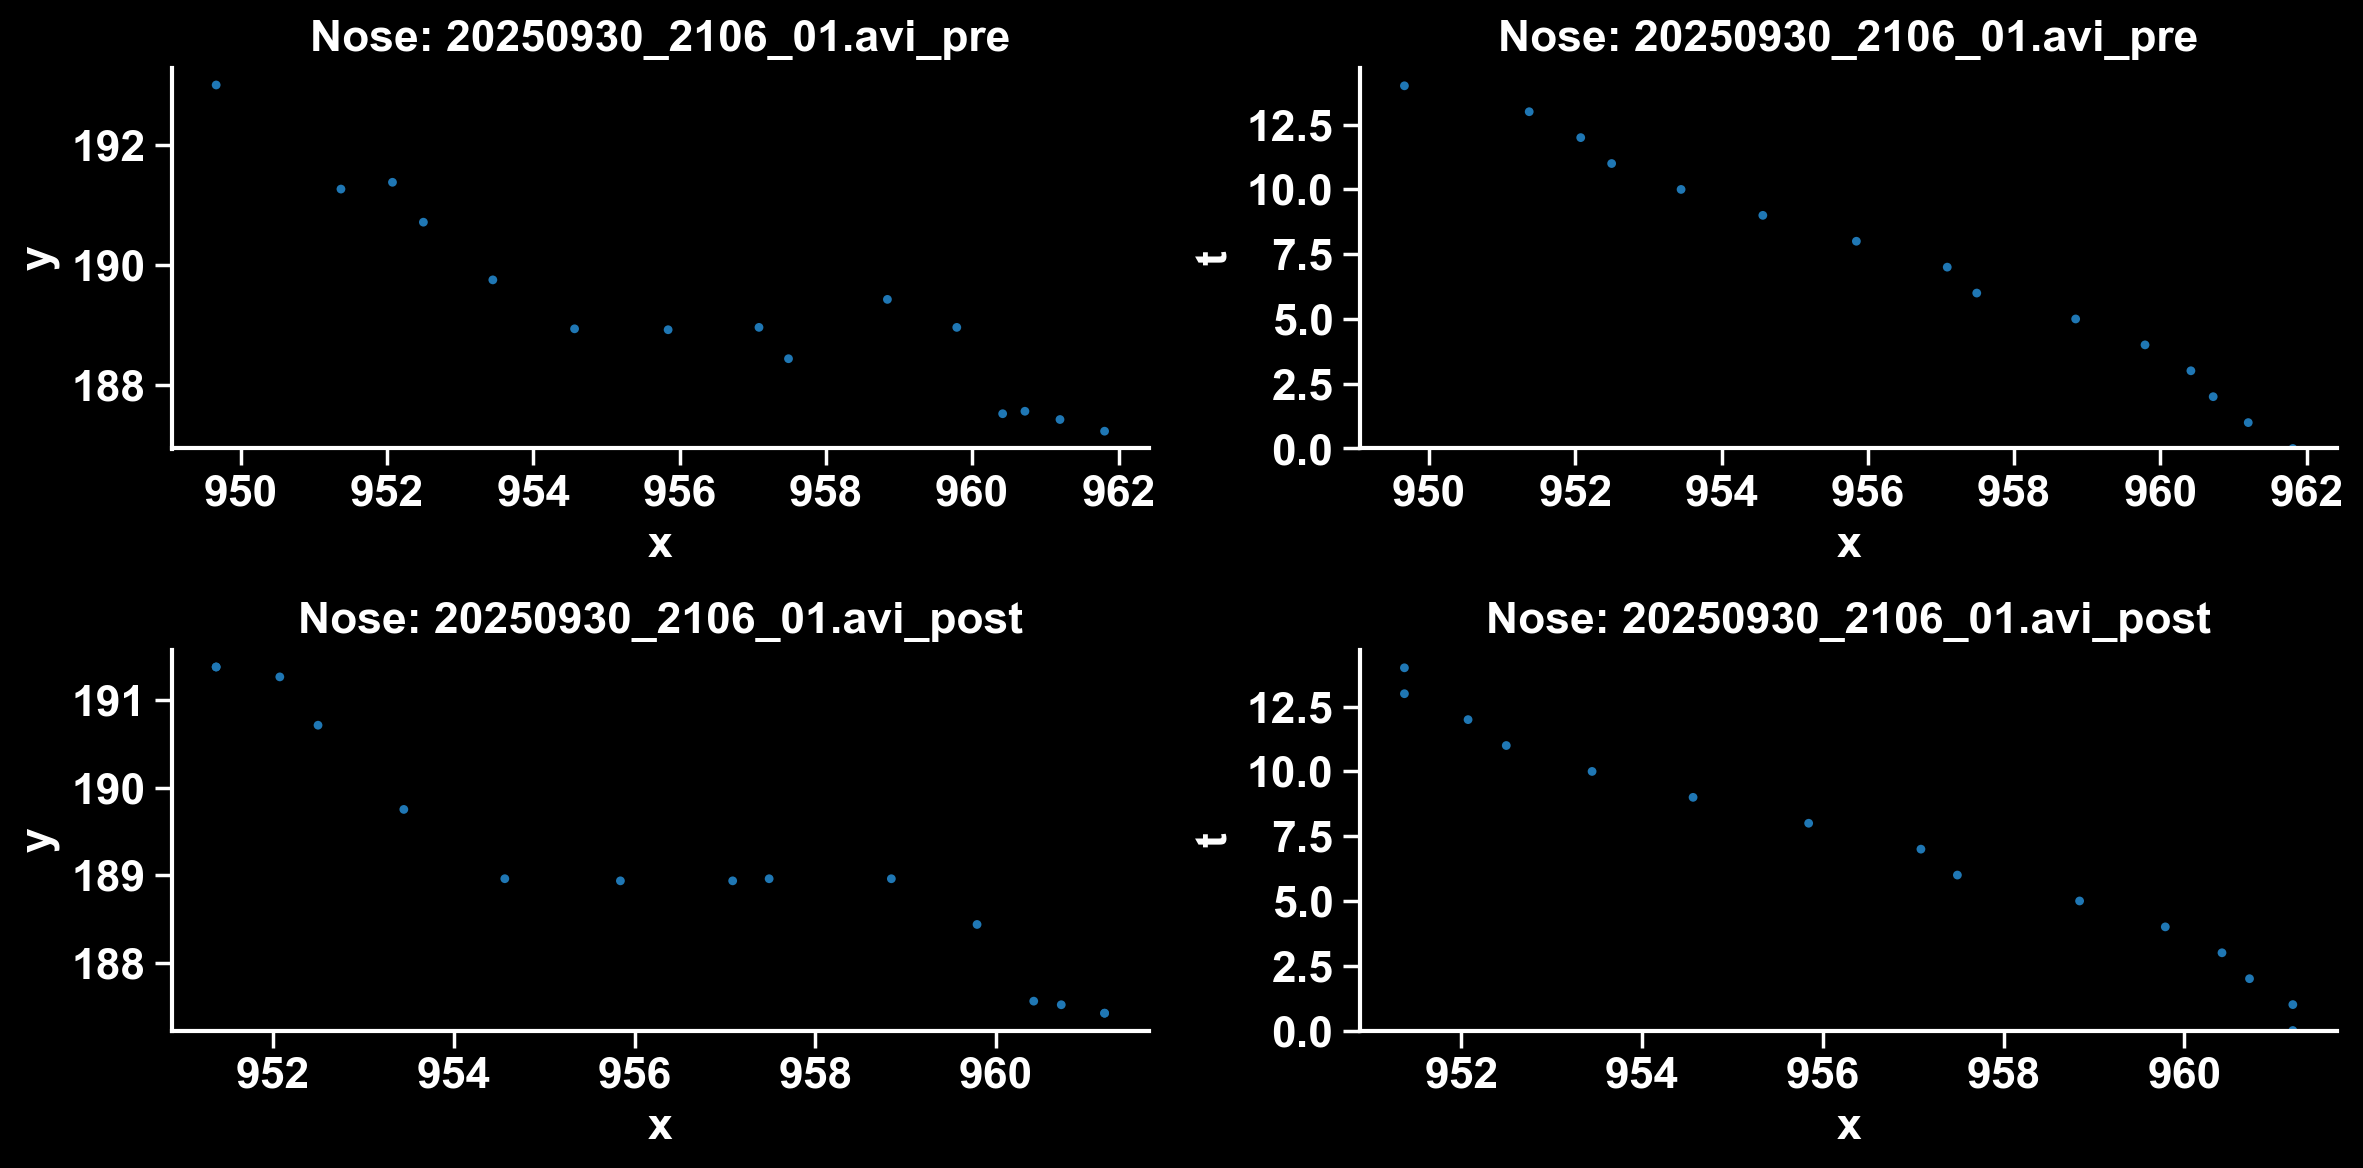

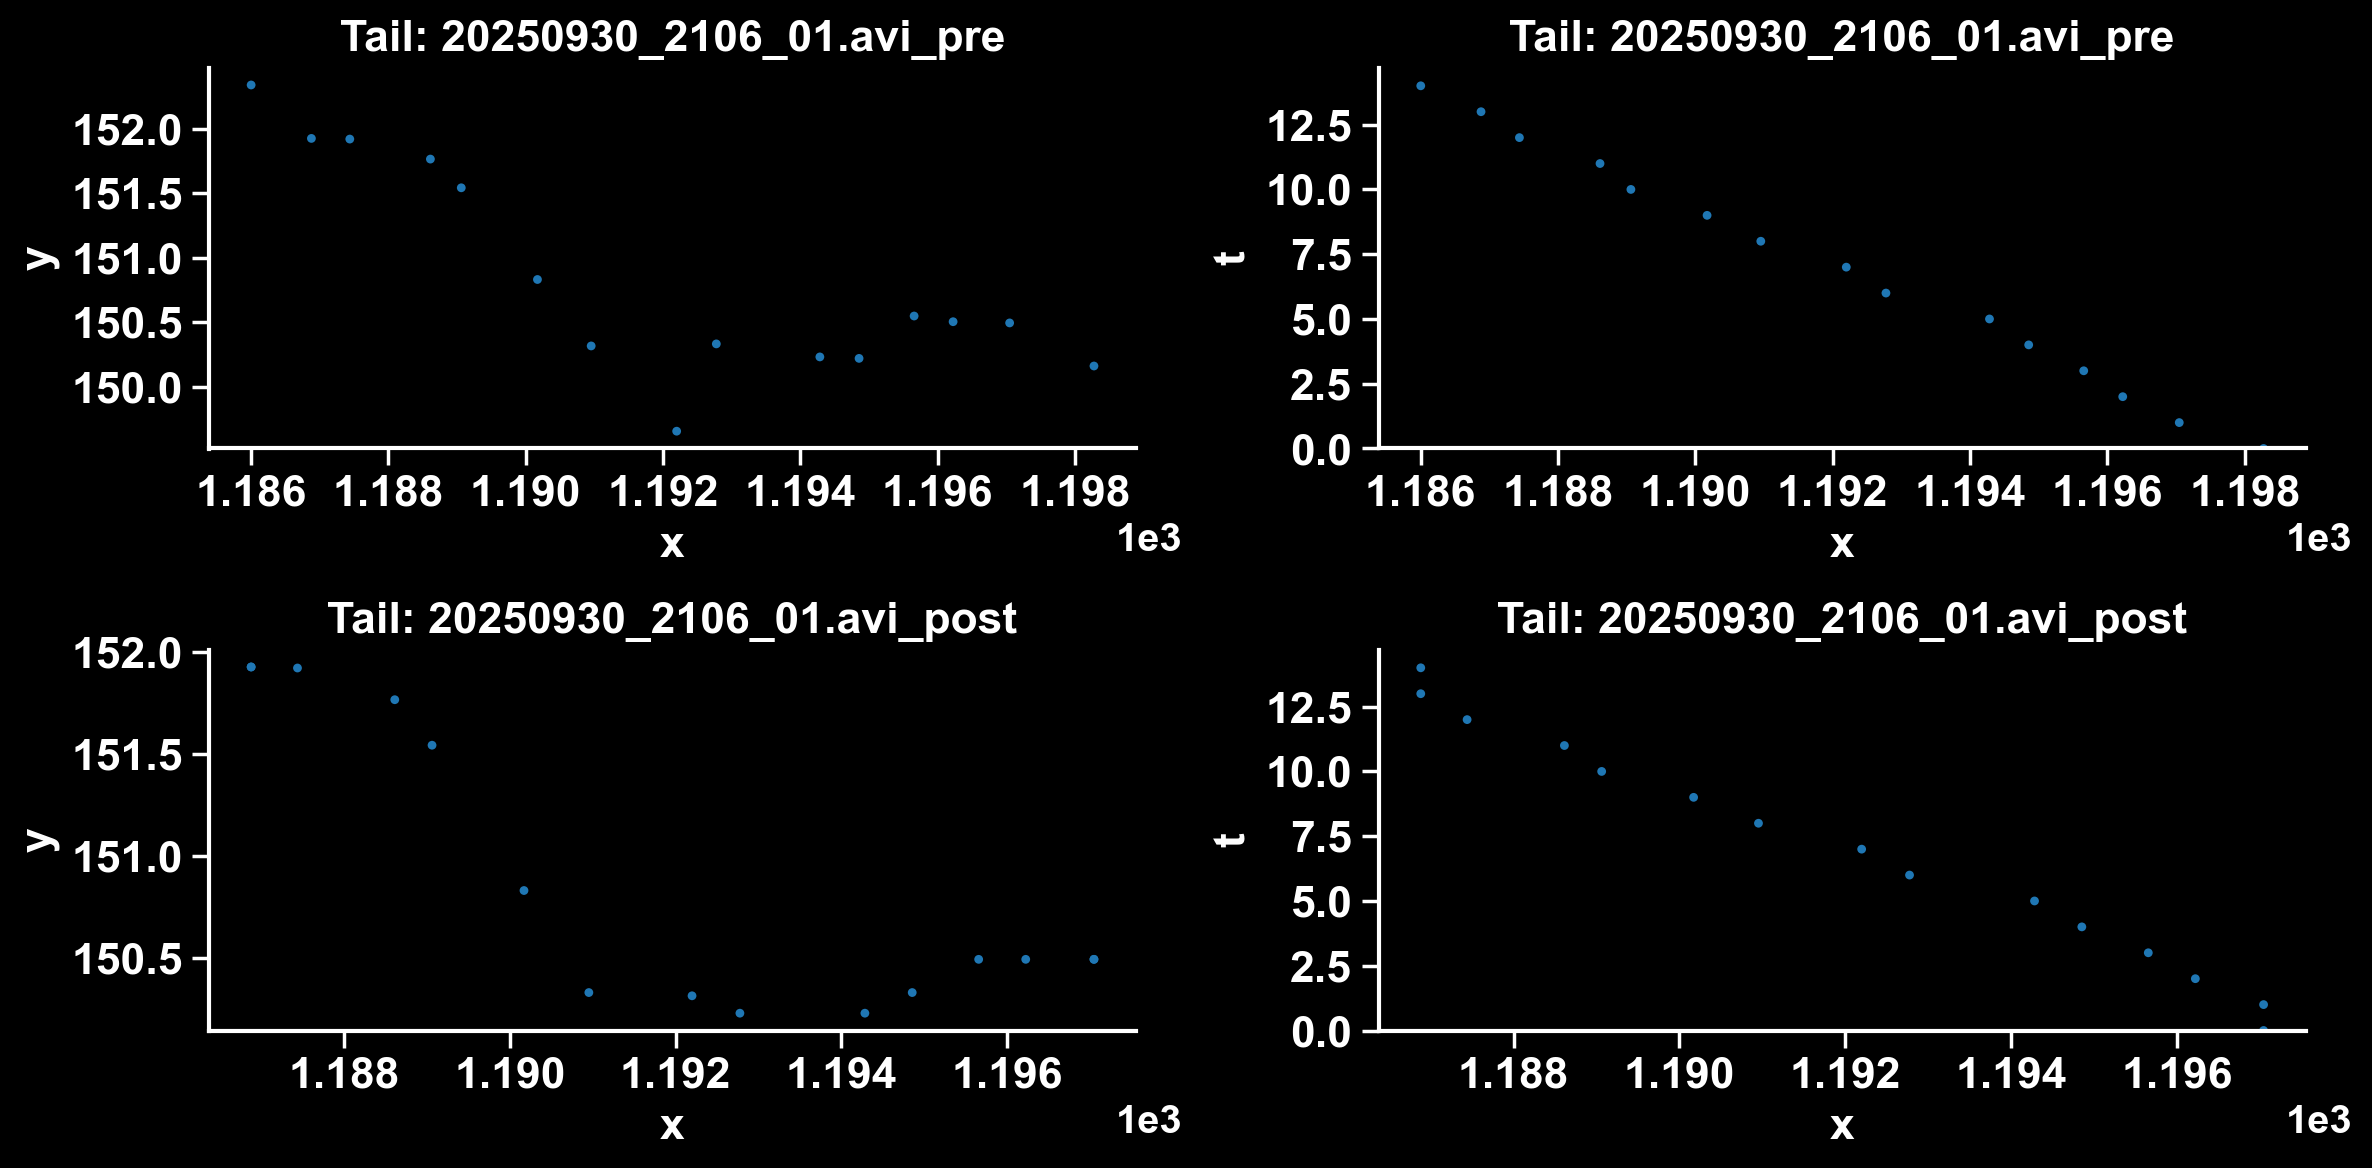

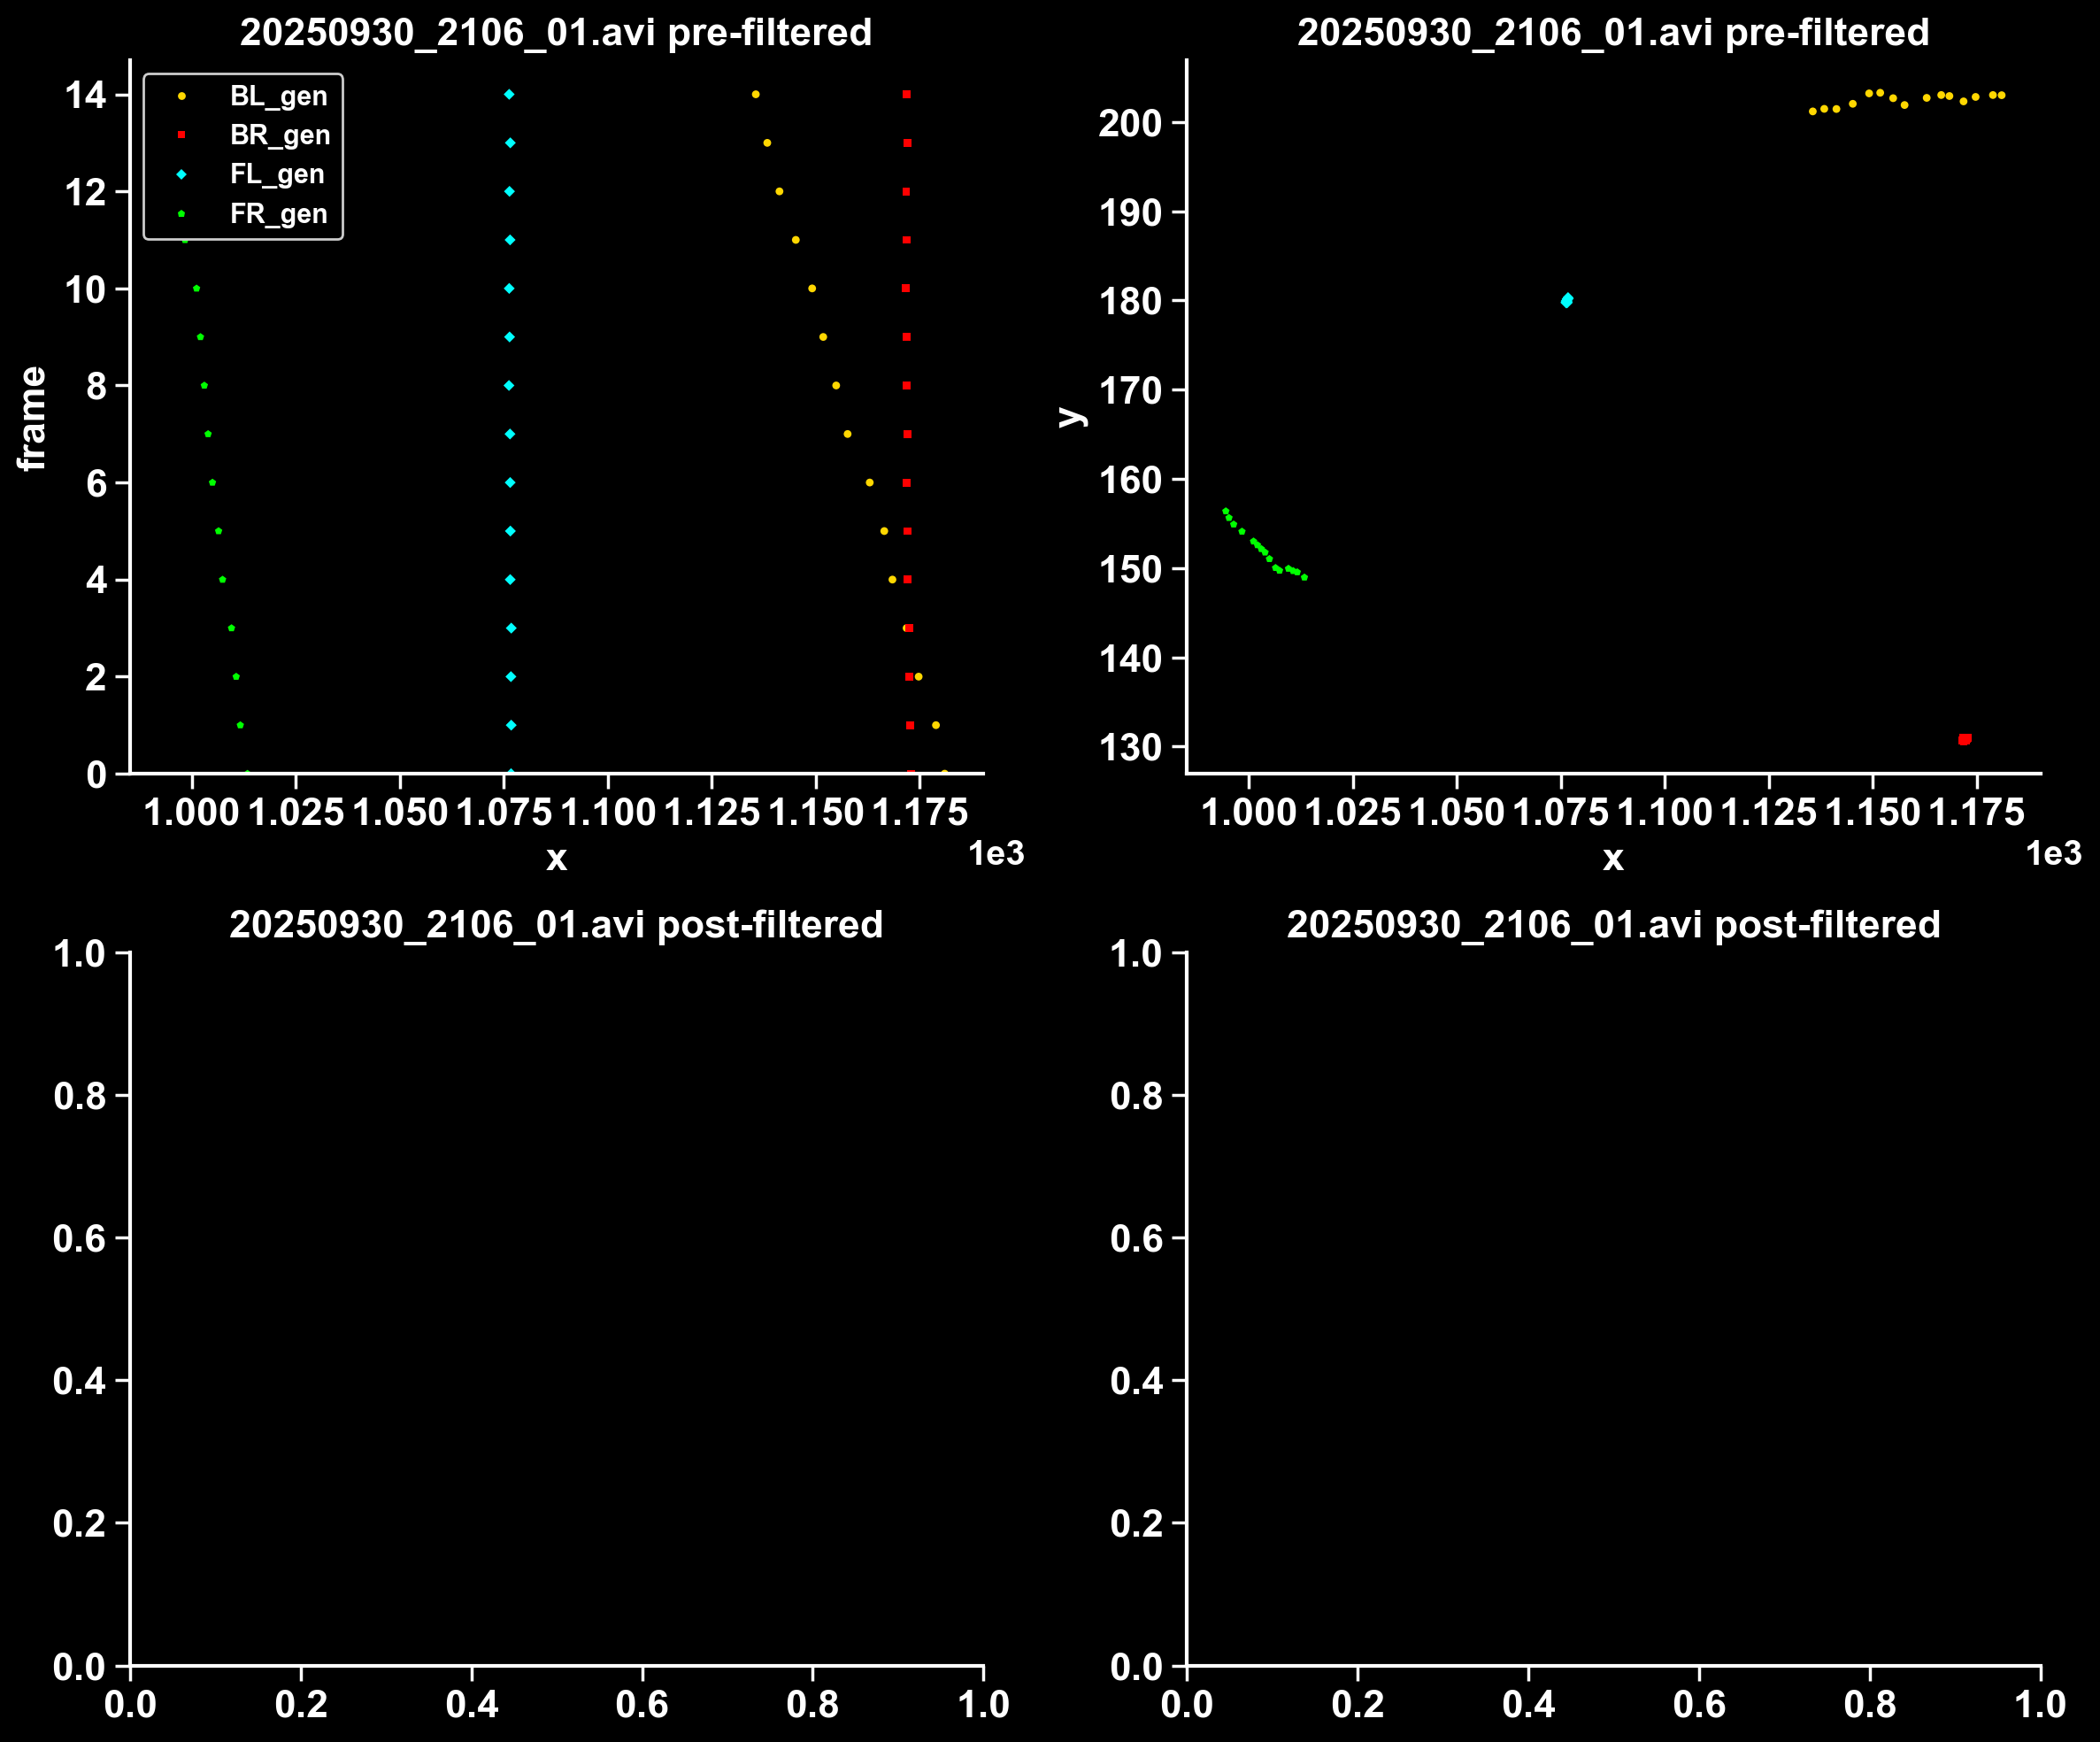

In [1]:
# IMPORT NECESSARY PACKAGES
import dlcfilterpipeline as dlp
import file_list_creator

# PASS INPUTS INTO FUNCTION, CAN LOOK AT __init__.py FOR EXAMPLE KWARGS
inputs = {
    'defaultdir':"/Users/paveyboys/Desktop/EXAMPLE/",
    'model_name':'DLC_Resnet50_mouse_trackingMay19shuffle1_snapshot_130',
    'dlc_venv_path': "/opt/anaconda3/envs/DEEPLABCUT/bin/python"}#"/opt/anaconda3/envs/DEEPLABCUT/bin/python"} # EDIT TO INCLUDE PATH TO PYTHON IN YOUR DEEPLABCUT ENVIRONMENT

# SELECT FILES TO PROCESS
file_list_creator.select_files_and_save_paths()
with open('file_list.txt', 'r') as file:
    video_list = [line.strip() for line in file]

# RUN PIPELINE FOR EACH VIDEO IN THE LIST
for video in video_list:
    pipe = dlp.manager(video,**inputs)
    pipe.batch_process()

### TRIAL EXCLUSION AND GAIT PARAMETER EXTRACTION

failure_logger.py: LOG SUCCESSFUL AND FAILED TRIALS


2025-08-29 15:48:12.583 python[44205:2254566] The class 'NSOpenPanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


All images reviewed.
CHOOSE CALIBRATION FILE


Exception in Tkinter callback
Traceback (most recent call last):
  File "/opt/anaconda3/envs/DLCPIPE/lib/python3.12/tkinter/__init__.py", line 1968, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "/Users/yikang/Documents/GitHub/DLC_FILTER_PIPELINE/job_functions/failure_logger.py", line 95, in next_image
    self.update_progress_color()
  File "/Users/yikang/Documents/GitHub/DLC_FILTER_PIPELINE/job_functions/failure_logger.py", line 74, in update_progress_color
    self.progress_canvas.itemconfig(rect, fill=color)
  File "/opt/anaconda3/envs/DLCPIPE/lib/python3.12/tkinter/__init__.py", line 2990, in itemconfigure
    return self._configure(('itemconfigure', tagOrId), cnf, kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/DLCPIPE/lib/python3.12/tkinter/__init__.py", line 1712, in _configure
    self.tk.call(_flatten((self._w, cmd)) + self._options(cnf))
_tkinter.TclError: invalid command name ".!canvas"


Select 15 inches (15 squares)
Click two endpoints of a known-length segment.
Meters per pixel: 0.000408
calculator_top_velocity.py: CALCULATE GAIT PARAMETERS FROM DATA.mat FILES
Running calculator_top_velocity.py in same folder as before
No such file: manually_determined_failures.txt, check paths or congratulations on no failures!
Calculating parameters for: 20250819_1101_01_DATA.mat
Calculating parameters for: 20250819_1105_10_DATA.mat
Select 15 inches (15 squares)
Calibration file not found
Using 0.0004083 meters per pixel
Meters per pixel: 0.0004083


OpenCV: Couldn't read video stream from file "/Volumes/jzellers/Active/1_Projects/K01_obesity/TEST_GAIT2/20250819/AVI/20250819_calibration_02.avi"


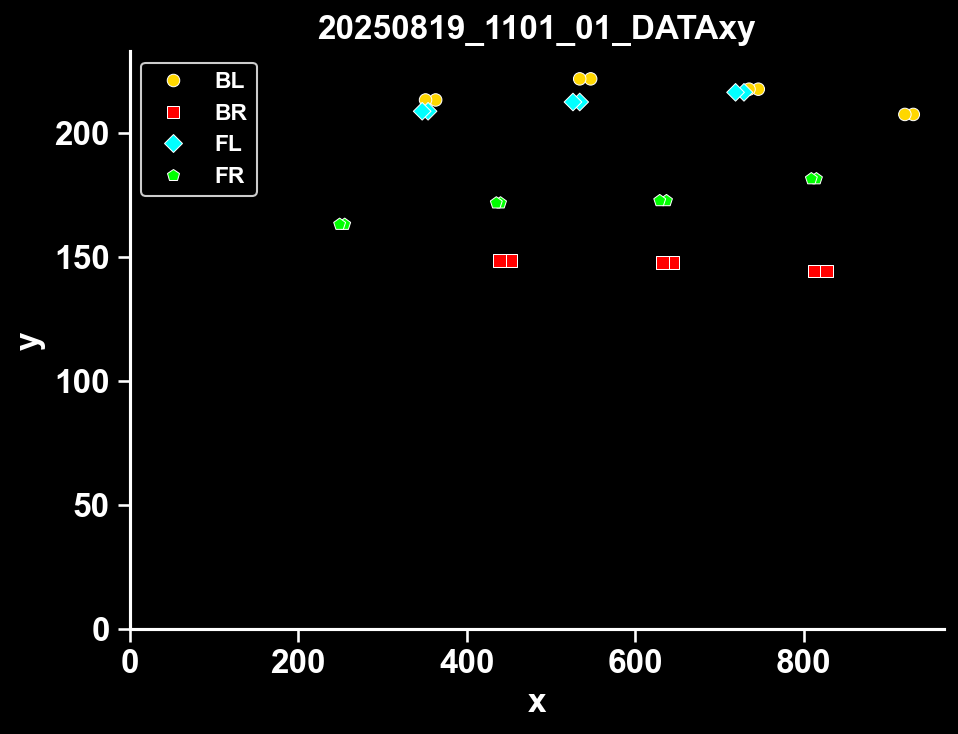

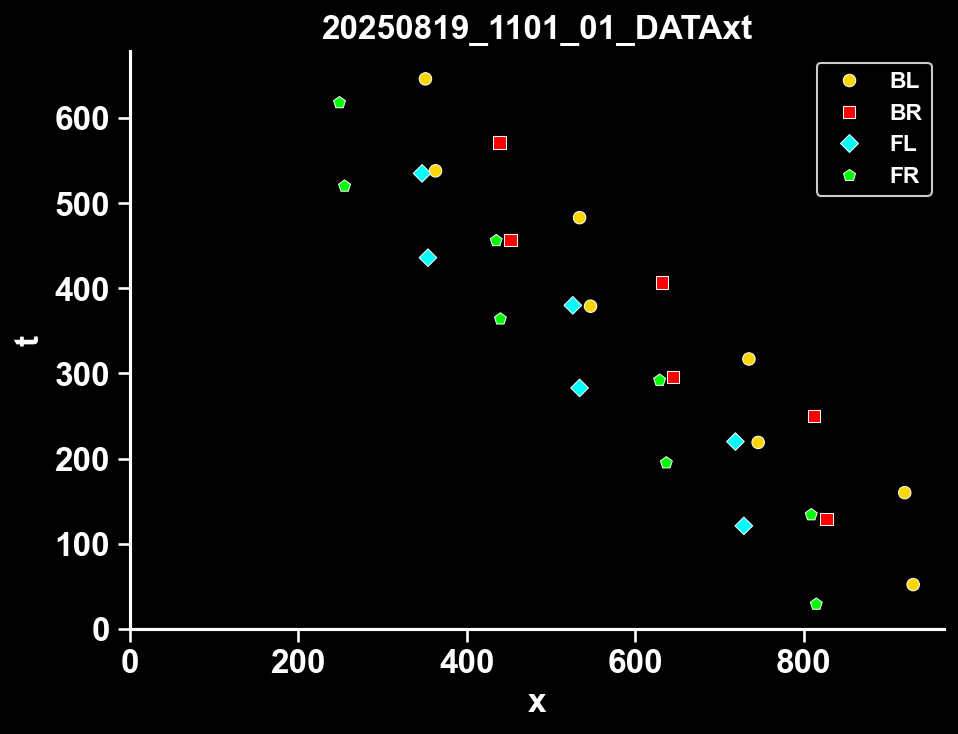

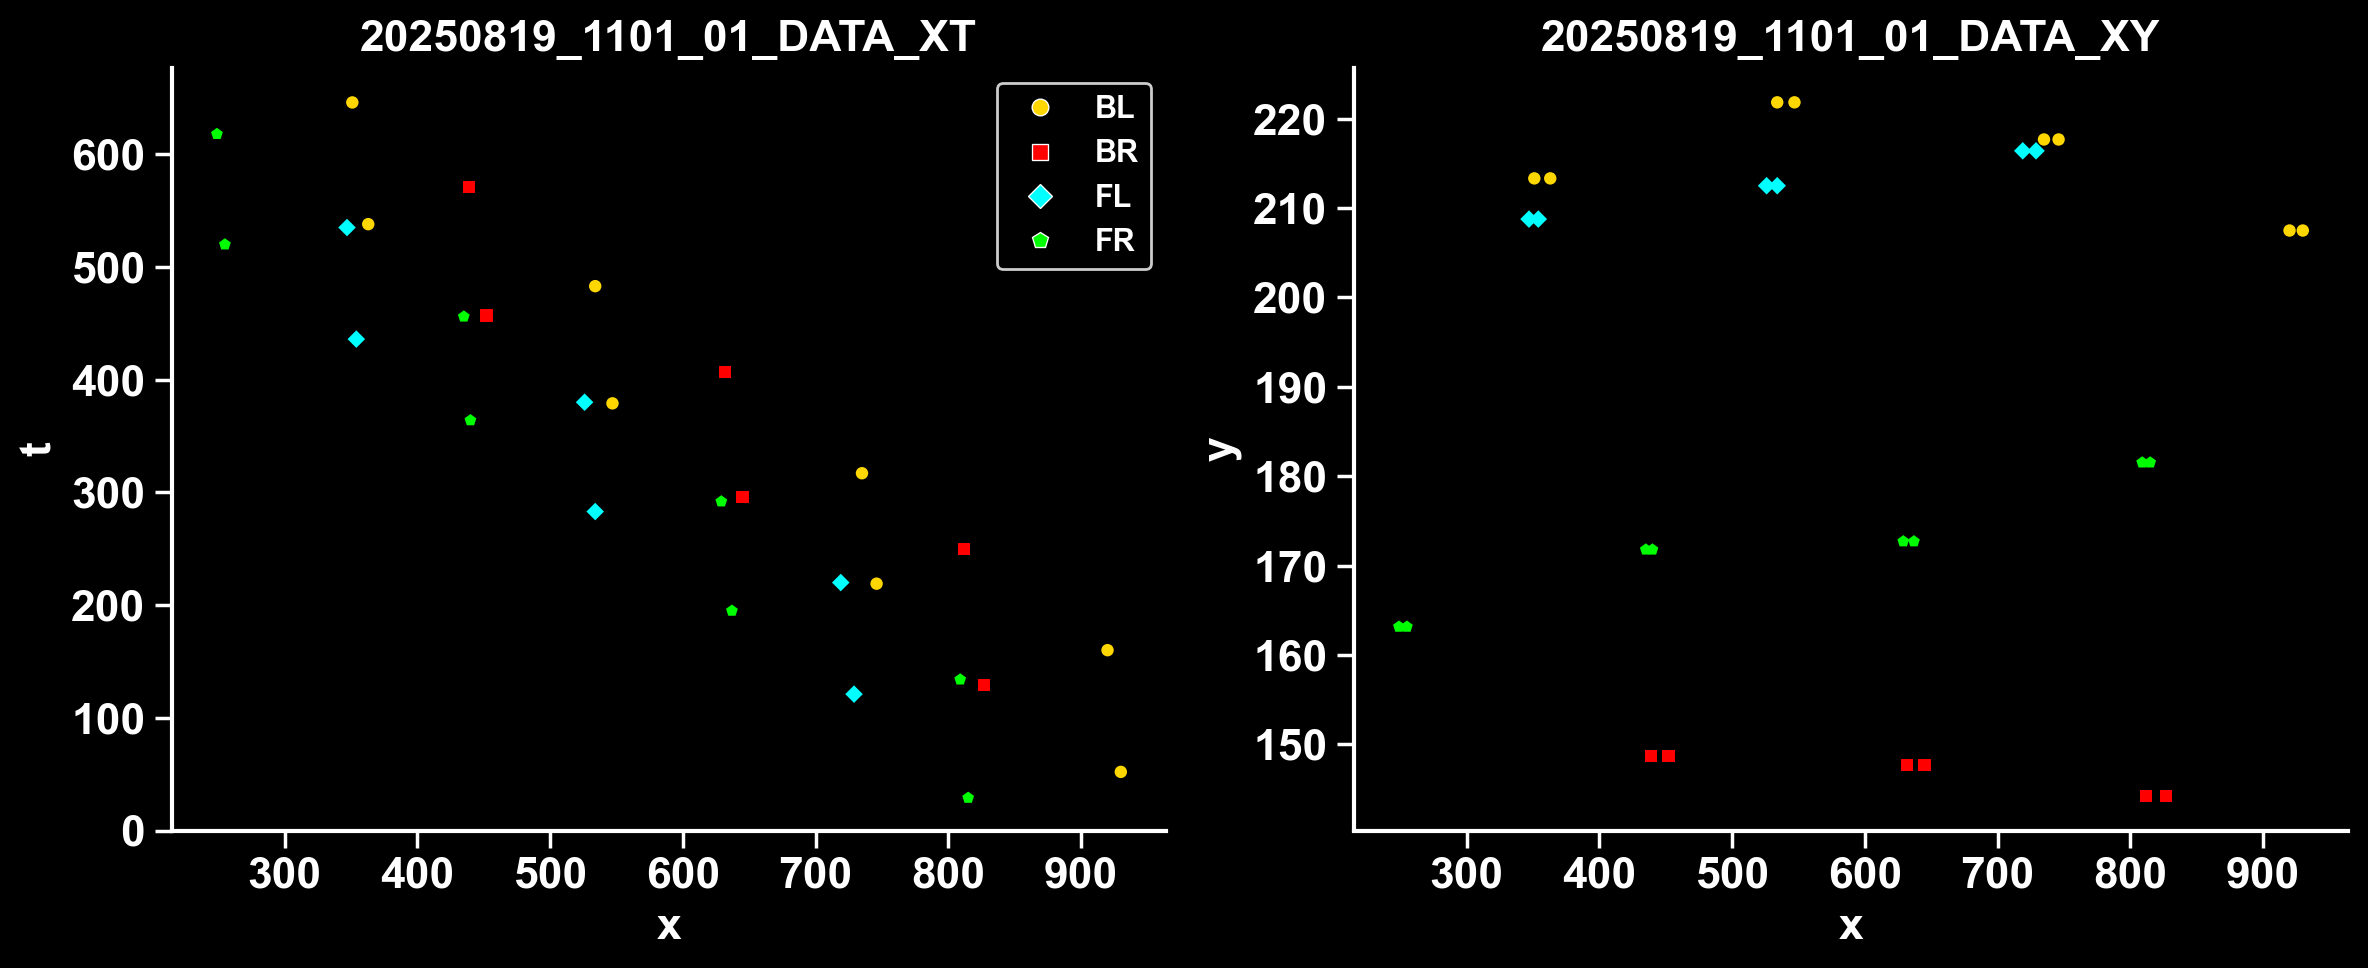

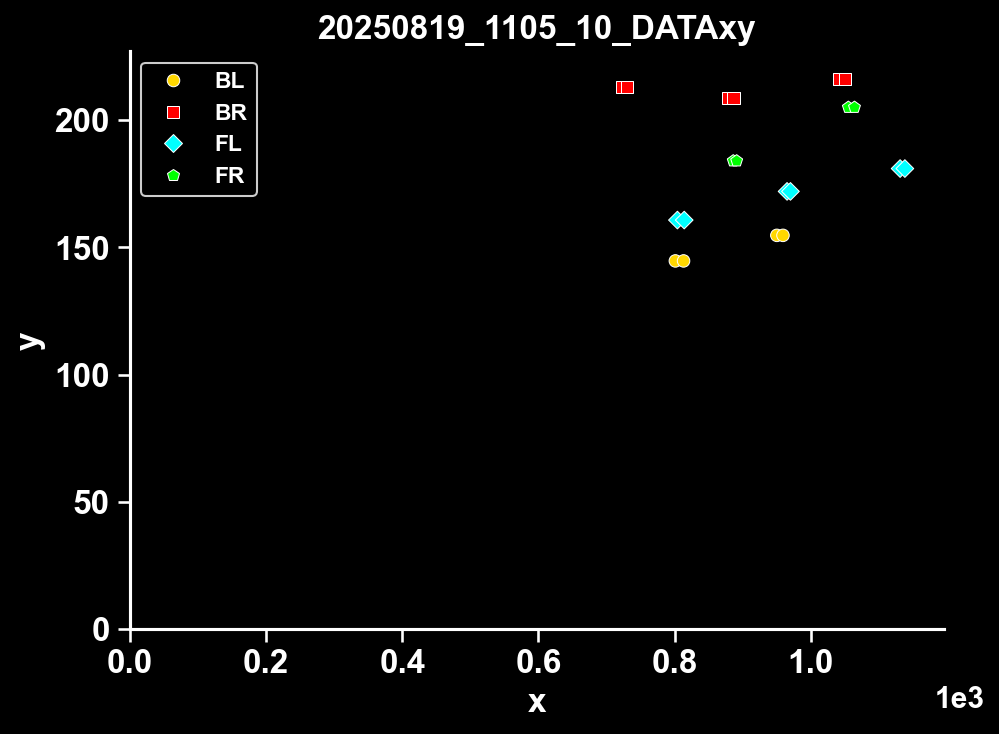

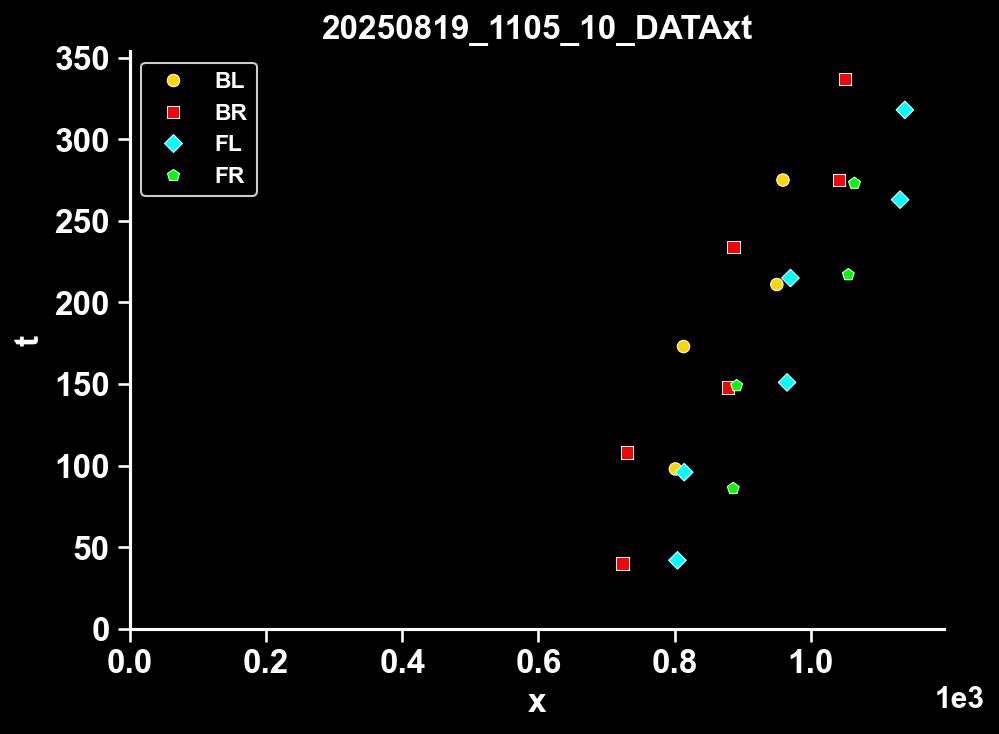

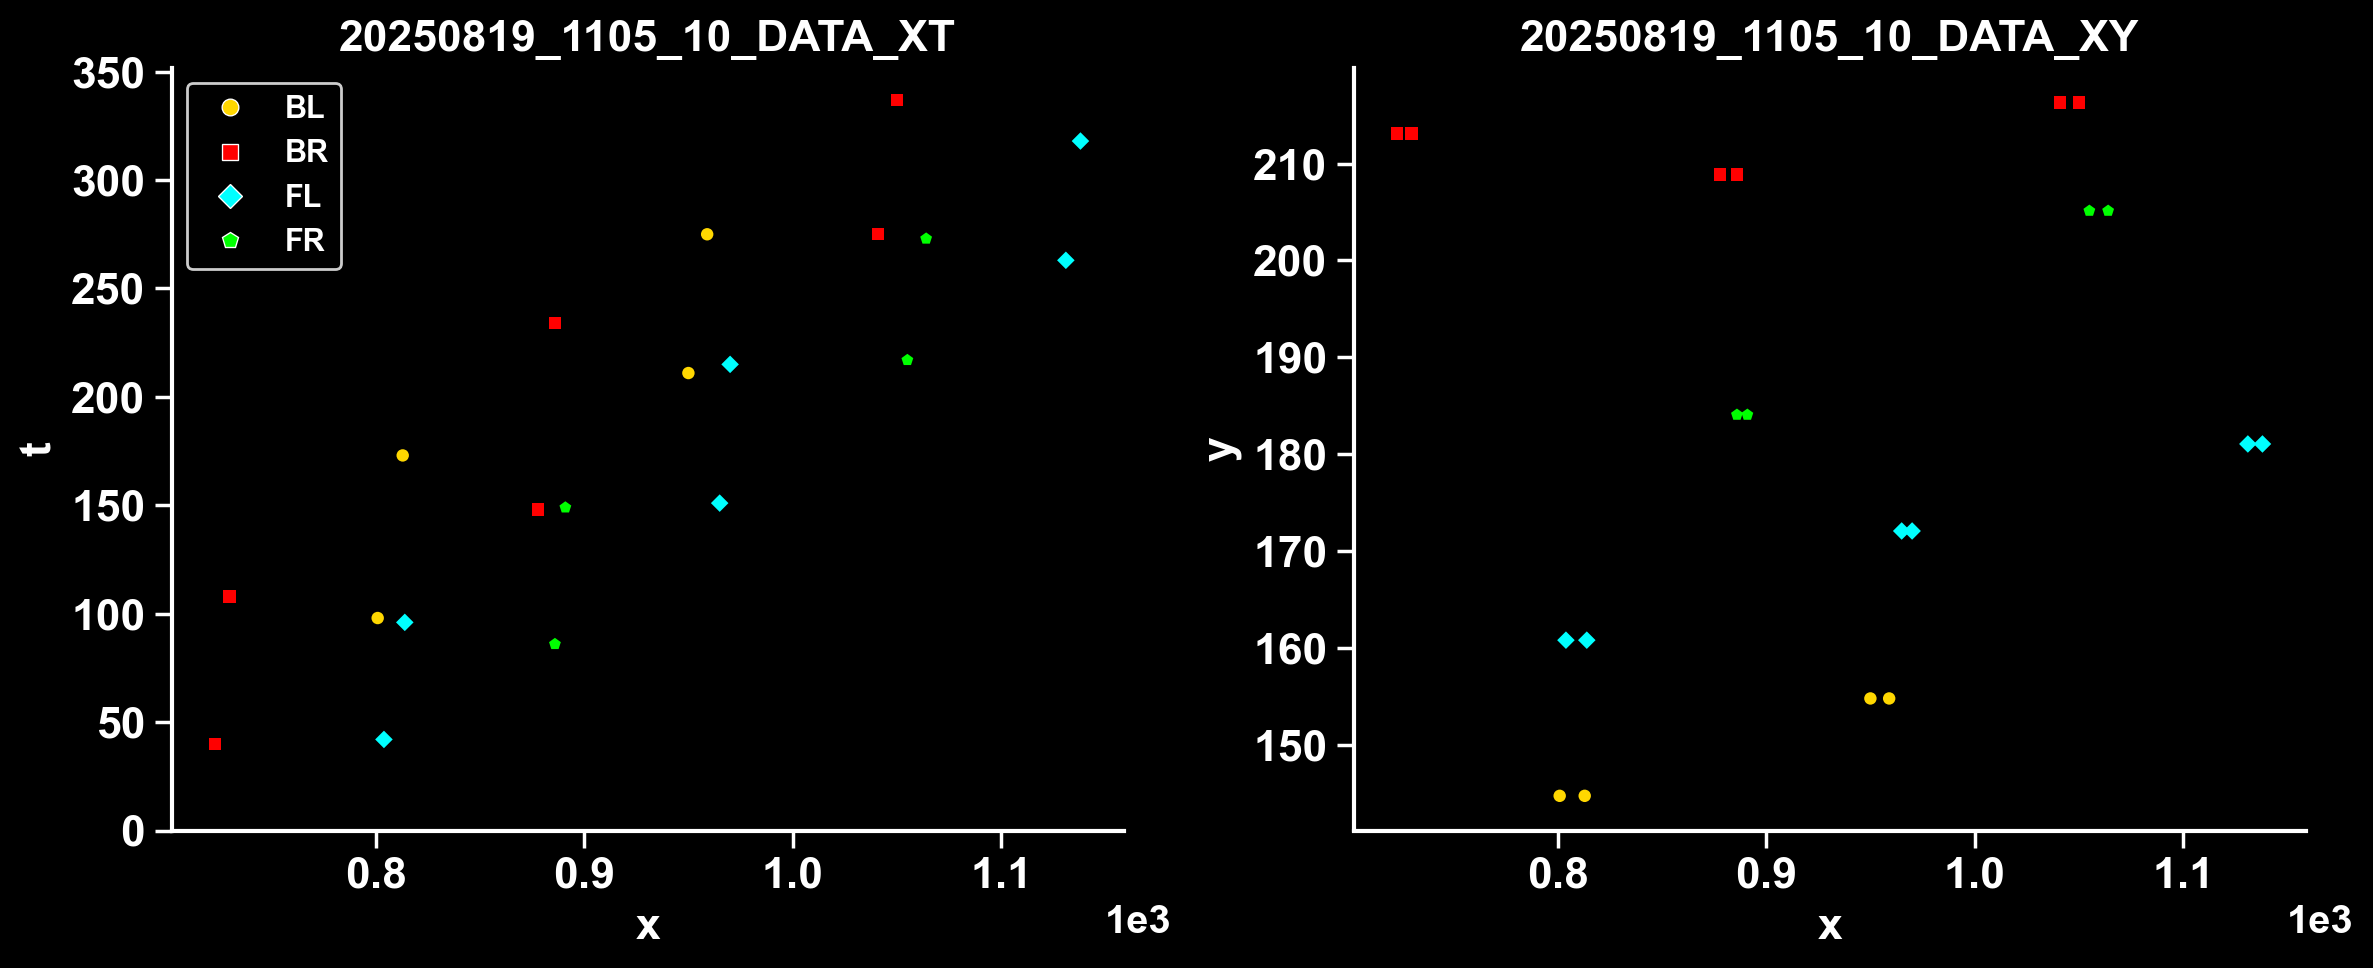

In [1]:
# IMPORT NECESSARY PACKAGES
import dlcfilterpipeline as dlp
import job_functions as jf

# OPEN FAILURE LOGGING GUI TO EXCLUDE TESTS (User chooses folder)
folder = jf.failure_logger()

# OPEN A CALIBRATION GUI TO CHOOSE THE SCALE (User chooses calibration_02 file)
dlp.extract_calibration_scale()

# RUN CALCULATOR_TOP_VELOCITY ON SAME FOLDER AS FAILURE_LOGGER (Automatic)
dlp.calculator_top_velocity(folder_path=folder)